# Tarea 2 Modulo 2

---
**Enunciado**

Calcular para cada uno de los ramos de accidentes personales y Gastos médicos:
1.	Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)
2.	Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?
3.	Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.
4.	Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?
5.	Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.
6.	Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?
7.	Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?
8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder, PowerTransformer
)
from scipy.stats import boxcox, shapiro
from scipy import stats

def resumen_ramo(df_ramo):
    """
    Funcion que nos ayuda a ver estadisticas descriptivas de nuestra base de datos
    """

    return pd.Series({

        'Numero_polizas': len(df_ramo),

        'Prima_total':
            df_ramo['prima_total'].sum(),

        'Prima_promedio':
            df_ramo['prima_total'].mean(),

        'Numero_siniestros':
            df_ramo['n_siniestros'].sum(),

        'Siniestro_promedio':
            df_ramo['monto_pagado'].mean(),

        'Siniestro_total':
            df_ramo['monto_pagado'].sum(),

        'Edad_promedio':
            df_ramo['edad'].mean()

    })



## Estadisticas descriptivas

In [2]:
df = pd.read_parquet("cartera_q1_2026_final.parquet")

ap = df[df['ramo'] == 'Accidentes Personales'].copy()

gmm = df[df['ramo'] == 'GMM'].copy()

ap['año_inicio'] = pd.to_datetime(
    ap['fecha_inicio_vigencia']
).dt.year

gmm['año_inicio'] = pd.to_datetime(
    gmm['fecha_inicio_vigencia']
).dt.year

print(ap.shape)
print(gmm.shape)

resumen = pd.DataFrame({

    'Accidentes Personales':
        resumen_ramo(ap),

    'GMM':
        resumen_ramo(gmm)

})

resumen_fmt = resumen.copy()

resumen_fmt.loc['Numero_polizas'] = (
    resumen.loc['Numero_polizas']
    .map(lambda x: f'{x:,.0f}')
)

resumen_fmt.loc['Prima_total'] = (
    resumen.loc['Prima_total']
    .map(lambda x: f'${x:,.2f}')
)

resumen_fmt.loc['Prima_promedio'] = (
    resumen.loc['Prima_promedio']
    .map(lambda x: f'${x:,.2f}')
)

resumen_fmt.loc['Numero_siniestros'] = (
    resumen.loc['Numero_siniestros']
    .map(lambda x: f'{x:,.0f}')
)

resumen_fmt.loc['Siniestro_promedio'] = (
    resumen.loc['Siniestro_promedio']
    .map(lambda x: f'${x:,.2f}')
)

resumen_fmt.loc['Siniestro_total'] = (
    resumen.loc['Siniestro_total']
    .map(lambda x: f'${x:,.2f}')
)

resumen_fmt.loc['Edad_promedio'] = (
    resumen.loc['Edad_promedio']
    .map(lambda x: f'{x:.2f}')
)

resumen_fmt

(5207, 53)
(22531, 53)


/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/2645872106.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5,207' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resumen_fmt.loc['Numero_polizas'] = (
/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/2645872106.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22,531' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resumen_fmt.loc['Numero_polizas'] = (


,Accidentes Personales,GMM
Numero_polizas,"5,207","22,531"
Prima_total,"$24,980,678.88","$731,022,322.30"
Prima_promedio,"$4,797.52","$32,445.18"
Numero_siniestros,"1,833","8,146"
Siniestro_promedio,"$4,284.89","$4,301.29"
Siniestro_total,"$22,311,397.14","$96,912,286.07"
Edad_promedio,43.49,43.30


In [4]:
print('Se observa que el ramo de GMM concentra una cartera significativamente más grande que la de Accidentes Personales, ' \
'\ncon 22,531 pólizas frente a 5,207. Esta diferencia también se refleja en la prima total, donde GMM acumula más de $731 millones, ' \
'\nmientras que Accidentes Personales registra aproximadamente $25 millones.')


Se observa que el ramo de GMM concentra una cartera significativamente más grande que la de Accidentes Personales, 
con 22,531 pólizas frente a 5,207. Esta diferencia también se refleja en la prima total, donde GMM acumula más de $731 millones, 
mientras que Accidentes Personales registra aproximadamente $25 millones.


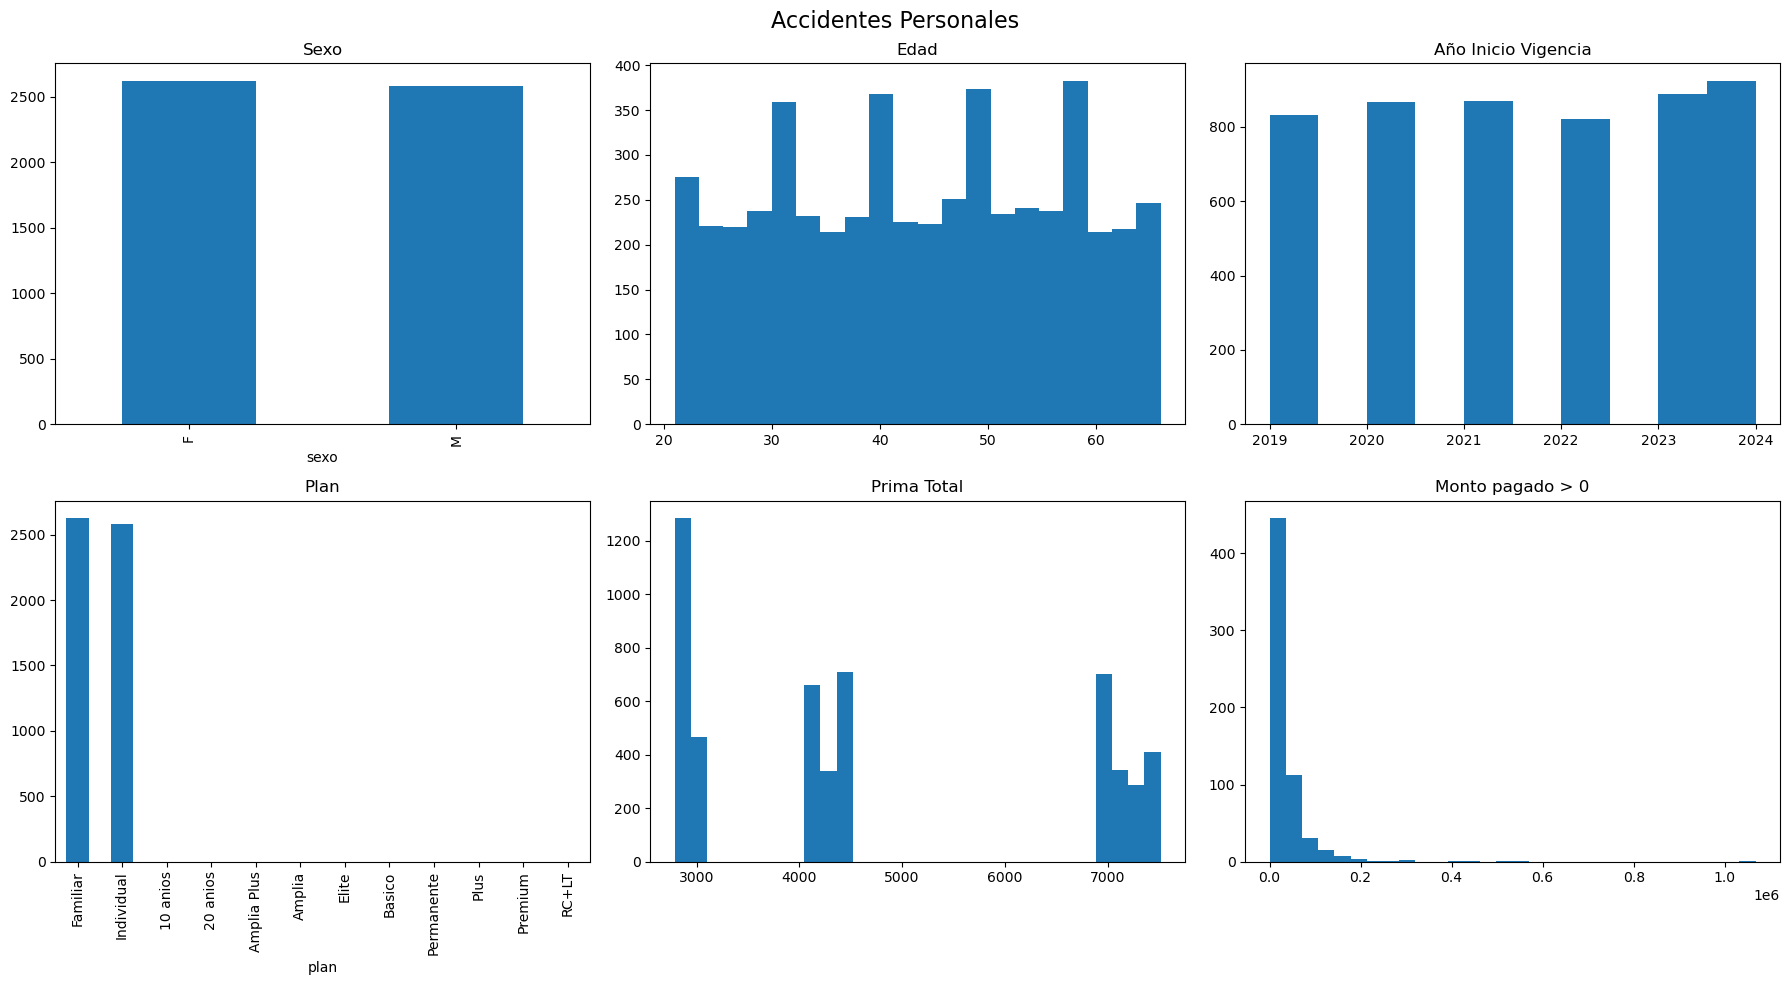

-Podemos notar que la cantidad de hombres y mujeres son casi iguales

- Para este ramo solo se ocupan 2 tipos de planes

-Los montos de las primas se concentran en ciertas cantidades, no hay una variedad de montos

-La cantidad d siniestro pagados han sido bajos lo cual es bueno


In [7]:
# Para ver la distribucion de los montos mayores a 0
ap_sin = ap[ap['monto_pagado'] > 0].copy()

fig, ax = plt.subplots(2,3, figsize=(18,10))

# Sexo
ap['sexo'].value_counts().plot(
    kind='bar',
    ax=ax[0,0]
)
ax[0,0].set_title('Sexo')

# Edad
ax[0,1].hist(
    ap['edad'],
    bins=20
)
ax[0,1].set_title('Edad')

# Año inicio
ax[0,2].hist(
    ap['año_inicio'],
    bins=10
)
ax[0,2].set_title('Año Inicio Vigencia')

# Plan
ap['plan'].value_counts().plot(
    kind='bar',
    ax=ax[1,0]
)
ax[1,0].set_title('Plan')

# Prima
ax[1,1].hist(
    ap['prima_total'],
    bins=30
)
ax[1,1].set_title('Prima Total')

# Siniestro
ax[1,2].hist(
    ap_sin['monto_pagado'],
    bins=30
)
ax[1,2].set_title('Monto pagado > 0')

plt.suptitle(
    'Accidentes Personales',
    fontsize=16
)

plt.tight_layout()

plt.show()

print('-Podemos notar que la cantidad de hombres y mujeres son casi iguales')
print('\n- Para este ramo solo se ocupan 2 tipos de planes')
print('\n-Los montos de las primas se concentran en ciertas cantidades, no hay una variedad de montos')
print('\n-La cantidad d siniestro pagados han sido bajos lo cual es bueno')


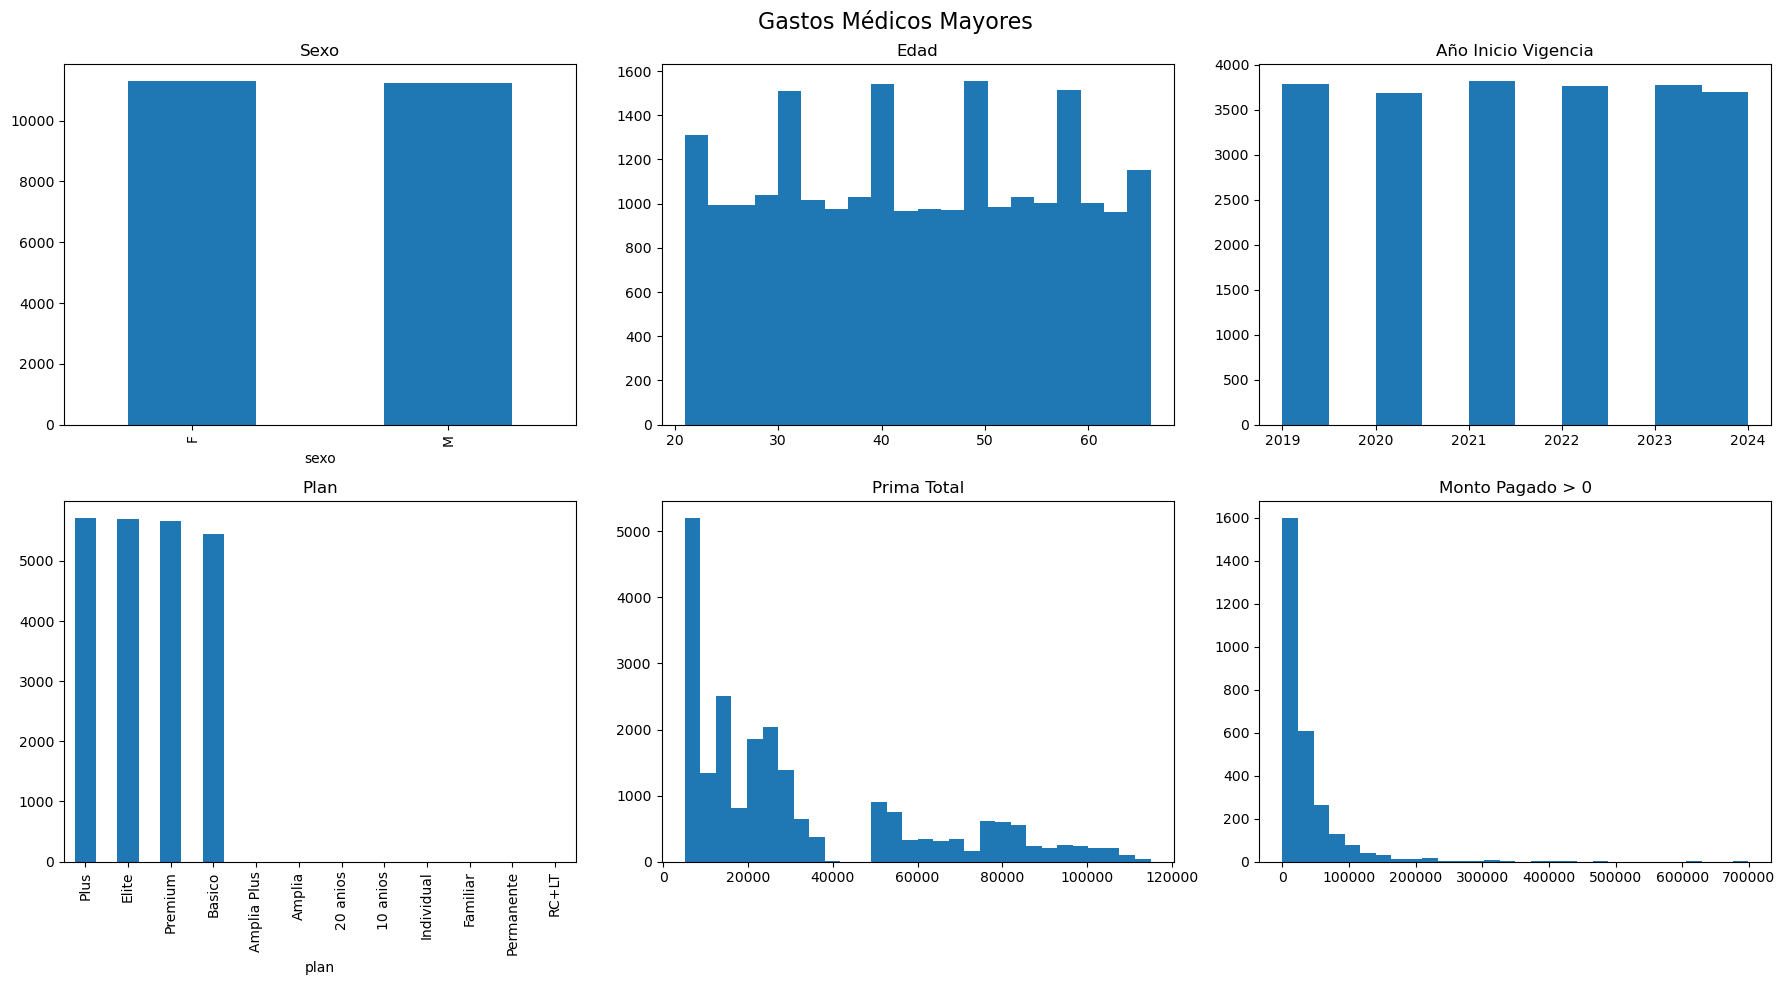

-Notemos que la prima toal tiene una mayor distribucion

-Tambien la cantidad de siniestros pagados han sido de un monto bajo


In [8]:
gmm_sin = gmm[gmm['monto_pagado'] > 0].copy()

fig, ax = plt.subplots(2, 3, figsize=(18,10))

# Sexo
gmm['sexo'].value_counts().plot(
    kind='bar',
    ax=ax[0,0]
)
ax[0,0].set_title('Sexo')

# Edad
ax[0,1].hist(
    gmm['edad'],
    bins=20
)
ax[0,1].set_title('Edad')

# Año inicio
ax[0,2].hist(
    gmm['año_inicio'],
    bins=10
)
ax[0,2].set_title('Año Inicio Vigencia')

# Plan
gmm['plan'].value_counts().plot(
    kind='bar',
    ax=ax[1,0]
)
ax[1,0].set_title('Plan')

# Prima
ax[1,1].hist(
    gmm['prima_total'],
    bins=30
)
ax[1,1].set_title('Prima Total')

# Siniestro
ax[1,2].hist(
    gmm_sin['monto_pagado'],
    bins=30
)
ax[1,2].set_title('Monto Pagado > 0')

plt.suptitle(
    'Gastos Médicos Mayores',
    fontsize=16
)

plt.tight_layout()

plt.show()

print('-Notemos que la prima toal tiene una mayor distribucion')
print('\n-Tambien la cantidad de siniestros pagados han sido de un monto bajo')

## Codificacion

### Accidentes personales

In [21]:
le = LabelEncoder()
 # Sexo contiene únicamente dos categorías, por lo que Label Encoding permite representar la información de forma compacta utilizando una sola columna.
ap['sexo_cod'] = le.fit_transform(ap['sexo'])


In [22]:
ap.columns

Index(['id_poliza', 'num_poliza', 'nombre', 'apellido_paterno',
       'apellido_materno', 'rfc', 'edad', 'sexo', 'estado_civil', 'ocupacion',
       'ramo', 'plan', 'fecha_emision', 'fecha_inicio_vigencia',
       'fecha_fin_vigencia', 'num_renovaciones', 'status_poliza',
       'motivo_baja', 'canal_venta', 'marca_vehiculo', 'modelo_vehiculo',
       'tipo_vehiculo', 'suma_asegurada', 'deducible', 'prima_neta',
       'prima_total', 'forma_pago', 'agente_id', 'estado', 'municipio',
       'codigo_postal', 'nombre_agente', 'region', 'tipo_agente',
       'comision_pct', 'n_siniestros', 'monto_reclamado', 'monto_pagado',
       'tiene_abierto', 'tipo_principal', 'prima_mensual', 'loss_ratio',
       'comision_est', 'nivel_riesgo', 'anio_emision', 'mes_emision',
       'trimestre', 'segmento_prima_fijo', 'cuartil_prima', 'cod_ramo',
       'anio_poliza', 'ramo_desde_codigo', 'año_inicio', 'sexo_cod'],
      dtype='object')

In [23]:
# Plan contiene múltiples categorías sin algun orden, por lo que se emplea One-Hot Encoding para evitar crear jerarquias.
ap_enc = ap.copy()
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    dtype=int
)

plan_ohe = ohe.fit_transform(ap_enc[['plan']])

plan_cols = ohe.get_feature_names_out(['plan'])

ap_enc[plan_cols] = plan_ohe

print("Muestra de la codificación:")
display(ap_enc[['plan'] + list(plan_cols)].drop_duplicates().sort_values('plan'))

Muestra de la codificación:


,plan,plan_Individual
15,Familiar,0
20,Individual,1


In [24]:
print(df['estado_civil'].value_counts())

estado_civil
Viudo          10160
Soltero         9990
Divorciado      9990
Casado          9955
Union libre     9905
Name: count, dtype: int64


In [25]:
# Variable categorica que no tiene un orden y son pocas categorias, por lo que es apta para utilizar One Hot Encoding
ec_ohe = ohe.fit_transform(ap_enc[['estado_civil']])

ec_cols = ohe.get_feature_names_out(['estado_civil'])

ap_enc[ec_cols] = ec_ohe

print("Muestra de la codificación:")
display(ap_enc[['estado_civil'] + list(ec_cols)].drop_duplicates().sort_values('estado_civil'))


Muestra de la codificación:


,estado_civil,estado_civil_Divorciado,estado_civil_Soltero,estado_civil_Union libre,estado_civil_Viudo
42,Casado,0,0,0,0
36,Divorciado,1,0,0,0
34,Soltero,0,1,0,0
15,Union libre,0,0,1,0
20,Viudo,0,0,0,1


In [26]:
print(df['canal_venta'].value_counts())

canal_venta
Agente           25043
Broker            9985
Banca Seguros     5017
Directo           4972
Digital           3491
Promotor          1492
Name: count, dtype: int64


In [27]:
# Similar a las anteriores, es una variables categorica con pocos valores y sin un orden jerarquico, por lo que es apta para el One Hot Encoding
canal_ohe = ohe.fit_transform(ap_enc[['canal_venta']])

canal_cols = ohe.get_feature_names_out(['canal_venta'])

ap_enc[canal_cols] = canal_ohe

print("Muestra de la codificación:")
display(ap_enc[['canal_venta'] + list(canal_cols)].drop_duplicates().sort_values('canal_venta'))


Muestra de la codificación:


,canal_venta,canal_venta_Banca Seguros,canal_venta_Broker,canal_venta_Digital,canal_venta_Directo,canal_venta_Promotor
15,Agente,0,0,0,0,0
33,Banca Seguros,1,0,0,0,0
34,Broker,0,1,0,0,0
142,Digital,0,0,1,0,0
57,Directo,0,0,0,1,0
687,Promotor,0,0,0,0,1


### Gastos Médicos

In [28]:
gmm['sexo_cod'] = le.fit_transform(gmm['sexo'])
print("Muestra de la codificación:")
display(
    gmm[['sexo','sexo_cod']]
    .drop_duplicates()
    .sort_values('sexo')
)

Muestra de la codificación:


,sexo,sexo_cod
10,F,0
2,M,1


In [29]:
gmm_enc = gmm.copy()

#Para One Hot Encoding utilizamos las mismas variables que en Accidentes personales
plan_ohe = ohe.fit_transform(gmm_enc[['plan']])

plan_cols = ohe.get_feature_names_out(['plan'])

gmm_enc[plan_cols] = plan_ohe

print("Muestra de la codificación:")
display(gmm_enc[['plan'] + list(plan_cols)].drop_duplicates().sort_values('plan'))

Muestra de la codificación:


,plan,plan_Elite,plan_Plus,plan_Premium
2,Basico,0,0,0
8,Elite,1,0,0
6,Plus,0,1,0
10,Premium,0,0,1


In [30]:
ec_ohe = ohe.fit_transform(gmm_enc[['estado_civil']])

ec_cols = ohe.get_feature_names_out(['estado_civil'])

gmm_enc[ec_cols] = ec_ohe

print("Muestra de la codificación:")
display(gmm_enc[['estado_civil'] + list(ec_cols)].drop_duplicates().sort_values('estado_civil'))

Muestra de la codificación:


,estado_civil,estado_civil_Divorciado,estado_civil_Soltero,estado_civil_Union libre,estado_civil_Viudo
7,Casado,0,0,0,0
6,Divorciado,1,0,0,0
41,Soltero,0,1,0,0
2,Union libre,0,0,1,0
11,Viudo,0,0,0,1


In [31]:
canal_ohe = ohe.fit_transform(gmm_enc[['canal_venta']])

canal_cols = ohe.get_feature_names_out(['canal_venta'])

gmm_enc[canal_cols] = canal_ohe

print("Muestra de la codificación:")
display(gmm_enc[['canal_venta'] + list(canal_cols)].drop_duplicates().sort_values('canal_venta'))

Muestra de la codificación:


,canal_venta,canal_venta_Banca Seguros,canal_venta_Broker,canal_venta_Digital,canal_venta_Directo,canal_venta_Promotor
6,Agente,0,0,0,0,0
2,Banca Seguros,1,0,0,0,0
8,Broker,0,1,0,0,0
13,Digital,0,0,1,0,0
7,Directo,0,0,0,1,0
76,Promotor,0,0,0,0,1


## Escalamiento

In [32]:
escaladores = {
    'MinMax': MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust': RobustScaler()
}

### Accidentes personales

In [33]:
#Escalamiento de la prima
ap_scal = ap.copy()

minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

ap_scal['prima_minmax'] = minmax.fit_transform(
    ap_scal[['prima_total']]
)

ap_scal['prima_standard'] = standard.fit_transform(
    ap_scal[['prima_total']]
)

ap_scal['prima_robust'] = robust.fit_transform(
    ap_scal[['prima_total']]
)

In [34]:
# Escalamiento de siniestros (utilizamos monto_pagado>0)
ap_sin_scal = ap_sin.copy()

ap_sin_scal['sin_minmax'] = minmax.fit_transform(
    ap_sin_scal[['monto_pagado']]
)

ap_sin_scal['sin_standard'] = standard.fit_transform(
    ap_sin_scal[['monto_pagado']]
)

ap_sin_scal['sin_robust'] = robust.fit_transform(
    ap_sin_scal[['monto_pagado']]
)

In [35]:
ap_sin_scal[['monto_pagado',
        'sin_minmax',
        'sin_standard',
        'sin_robust']].describe()

,monto_pagado,sin_minmax,sin_standard,sin_robust
count,6.230000e+02,623.000000,6.230000e+02,623.000000
mean,3.581284e+04,0.033496,-5.132331e-17,0.544564
std,6.651039e+04,0.062282,1.000804e+00,2.124767
min,4.260000e+01,0.000000,-5.382464e-01,-0.598166
25%,8.157490e+03,0.007599,-4.161390e-01,-0.338925
50%,1.876667e+04,0.017534,-2.564992e-01,0.000000
75%,3.945993e+04,0.036911,5.487900e-02,0.661075
max,1.067934e+06,1.000000,1.553066e+01,33.517105


In [36]:
ap_scal[['prima_total',
        'prima_minmax',
        'prima_standard',
        'prima_robust']].describe()

,prima_total,prima_minmax,prima_standard,prima_robust
count,5207.000000,5207.000000,5.207000e+03,5207.000000
mean,4797.518510,0.425439,-2.592724e-16,0.125526
std,1804.026334,0.381175,1.000096e+00,0.456337
min,2784.000000,0.000000,-1.116232e+00,-0.383803
25%,3006.720000,0.047059,-9.927629e-01,-0.327465
50%,4301.280000,0.320588,-2.750992e-01,0.000000
75%,6960.000000,0.882353,1.198812e+00,0.672535
max,7516.800000,1.000000,1.507485e+00,0.813380


In [37]:
print('Para la prima, notemos que con StandardScaler, la media se aproxima a 0 y la desviación estándar a 1, facilitando la comparación con otras variables.')
print('\nCon RobustScaler, la mediana se convierte en 0 y el escalamiento se realiza utilizando IQR, reduciendo la influencia de valores extremos.')
print('\nLa diferencia entre el máximo y el tercer cuartil no es tan grande en primas, lo que indica que esta variable presenta una dispersión moderada y relativamente pocos valores extremos.')

Para la prima, notemos que con StandardScaler, la media se aproxima a 0 y la desviación estándar a 1, facilitando la comparación con otras variables.

Con RobustScaler, la mediana se convierte en 0 y el escalamiento se realiza utilizando IQR, reduciendo la influencia de valores extremos.

La diferencia entre el máximo y el tercer cuartil no es tan grande en primas, lo que indica que esta variable presenta una dispersión moderada y relativamente pocos valores extremos.


In [38]:
print('Para el caso del monto pagado, MinMaxScaler comprime la mayoría de los datos cerca de cero.')
print('\nStandardScaler genera valores muy altos para los siniestros extremos, por su lado RobustScaler reduce el efecto ' \
'\nde dichos valores al utilizar la mediana y el IQR como referencia.')

Para el caso del monto pagado, MinMaxScaler comprime la mayoría de los datos cerca de cero.

StandardScaler genera valores muy altos para los siniestros extremos, por su lado RobustScaler reduce el efecto 
de dichos valores al utilizar la mediana y el IQR como referencia.


### Gastos Medicos

In [39]:
gmm_scal = gmm.copy()

gmm_scal['prima_minmax'] = minmax.fit_transform(
    gmm_scal[['prima_total']]
)

gmm_scal['prima_standard'] = standard.fit_transform(
    gmm_scal[['prima_total']]
)

gmm_scal['prima_robust'] = robust.fit_transform(
    gmm_scal[['prima_total']]
)

In [40]:
gmm_sin_scal = gmm_sin.copy()

gmm_sin_scal['sin_minmax'] = minmax.fit_transform(
    gmm_sin_scal[['monto_pagado']]
)

gmm_sin_scal['sin_standard'] = standard.fit_transform(
    gmm_sin_scal[['monto_pagado']]
)

gmm_sin_scal['sin_robust'] = robust.fit_transform(
    gmm_sin_scal[['monto_pagado']]
)

In [41]:
gmm_sin_scal[['monto_pagado',
        'sin_minmax',
        'sin_standard',
        'sin_robust']].describe()

,monto_pagado,sin_minmax,sin_standard,sin_robust
count,2813.000000,2813.000000,2.813000e+03,2813.000000
mean,34451.576989,0.049238,-8.840738e-18,0.449743
std,48622.002554,0.069590,1.000178e+00,1.451015
min,49.100000,0.000000,-7.076754e-01,-0.576922
25%,8135.100000,0.011573,-5.413425e-01,-0.335613
50%,19381.150000,0.027669,-3.100059e-01,0.000000
75%,41644.060000,0.059532,1.479528e-01,0.664387
max,698744.320000,1.000000,1.366482e+01,20.274075


In [42]:
gmm_scal[['prima_total',
        'prima_minmax',
        'prima_standard',
        'prima_robust']].describe()

,prima_total,prima_minmax,prima_standard,prima_robust
count,22531.000000,22531.000000,2.253100e+04,22531.000000
mean,32445.178745,0.248946,1.160533e-16,0.241329
std,28387.431655,0.258472,1.000022e+00,0.658981
min,5104.000000,0.000000,-9.631652e-01,-0.393365
25%,9493.440000,0.039967,-8.085356e-01,-0.291469
50%,22049.280000,0.154289,-3.662230e-01,0.000000
75%,52571.200000,0.432196,7.089922e-01,0.708531
max,114931.870000,1.000000,2.905811e+00,2.156161


In [43]:
print('-Para la priam el valor máximo supera los $114 mil, mientras que la mediana es cercana a $22 mil, lo que indica una distribución más dispersa ' \
'\nque la observada en Accidentes Personales.')
print('\nTanto en Accidentes Personales como en GMM, las variables de monto pagado presentan una marcada asimetría positiva y ' \
'\nvalores extremos característicos de la severidad de siniestros. Debido a esta característica, RobustScaler resulta particularmente ' \
'\nadecuado para este tipo de información, ya que conserva mejor la estructura central de los datos y reduce el impacto de observaciones extraordinariamente grandes. ' \
'\nLas primas muestran una dispersión menor que los siniestros, aunque en GMM se observa una variabilidad considerablemente mayor que en Accidentes Personales.')

-Para la priam el valor máximo supera los $114 mil, mientras que la mediana es cercana a $22 mil, lo que indica una distribución más dispersa 
que la observada en Accidentes Personales.

Tanto en Accidentes Personales como en GMM, las variables de monto pagado presentan una marcada asimetría positiva y 
valores extremos característicos de la severidad de siniestros. Debido a esta característica, RobustScaler resulta particularmente 
adecuado para este tipo de información, ya que conserva mejor la estructura central de los datos y reduce el impacto de observaciones extraordinariamente grandes. 
Las primas muestran una dispersión menor que los siniestros, aunque en GMM se observa una variabilidad considerablemente mayor que en Accidentes Personales.


## Transformaciones

### Accidentes personales

In [44]:
# Transformacion logaritmica
ap_trans = ap_sin.copy()
ap_trans['log'] = np.log1p(ap_trans['monto_pagado'])

In [45]:
# Transformaicon Box Cox
ap_trans['boxcox'], lambda_ap = boxcox(ap_trans['monto_pagado'])

In [46]:
pt_ap = PowerTransformer(method='yeo-johnson')
# Transformacion Yeo-Johnson
ap_trans['yeojohnson'] = pt_ap.fit_transform(ap_trans[['monto_pagado']])

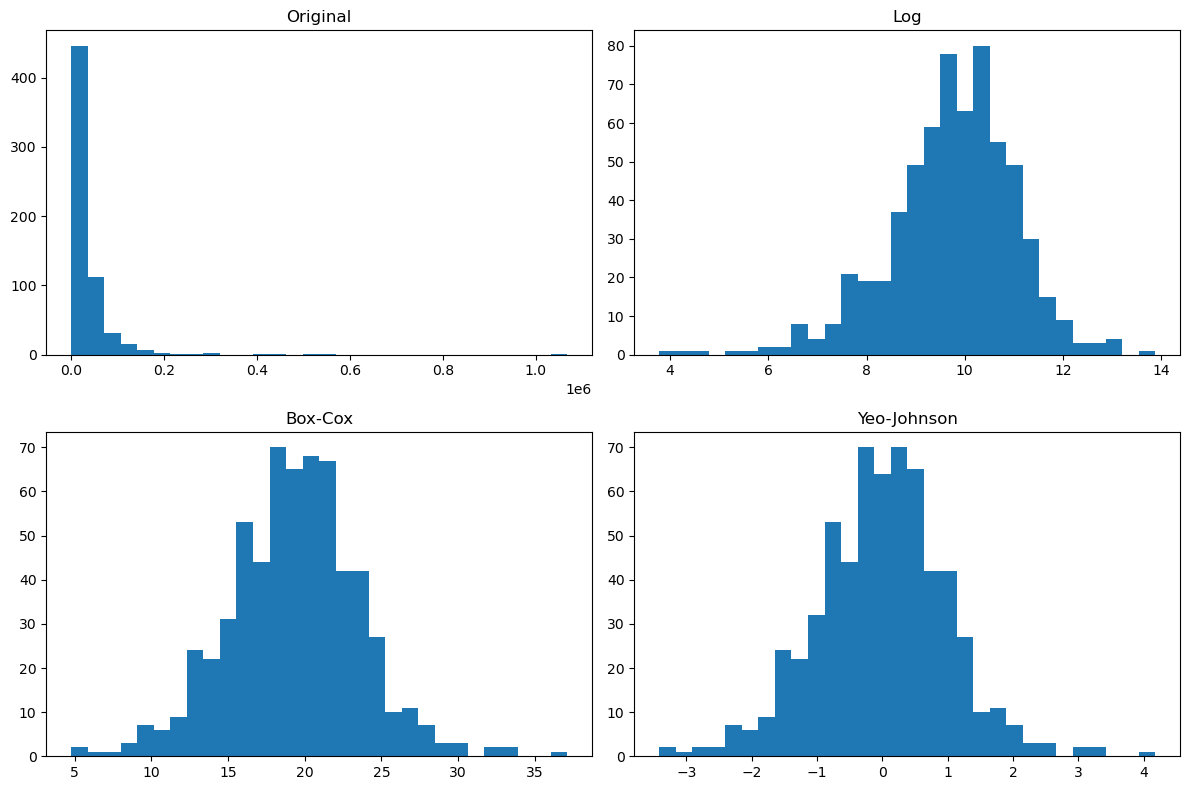

Se observa una clara transformacion de los datos


In [47]:
fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].hist(ap_trans['monto_pagado'], bins=30)
ax[0,0].set_title('Original')

ax[0,1].hist(ap_trans['log'], bins=30)
ax[0,1].set_title('Log')

ax[1,0].hist(ap_trans['boxcox'], bins=30)
ax[1,0].set_title('Box-Cox')

ax[1,1].hist(ap_trans['yeojohnson'], bins=30)
ax[1,1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

print('Se observa una clara transformacion de los datos')

### GMM

In [48]:
gmm_trans = gmm_sin.copy()

# Transformacion logaritmica
gmm_trans['log'] = np.log1p(gmm_trans['monto_pagado'])

# Transformaicon Box Cox
gmm_trans['boxcox'], lambda_gmm = boxcox(gmm_trans['monto_pagado'])

pt_gmm = PowerTransformer(method='yeo-johnson')
# Transformacion Yeo-Johnson
gmm_trans['yeojohnson'] = pt_gmm.fit_transform(gmm_trans[['monto_pagado']])

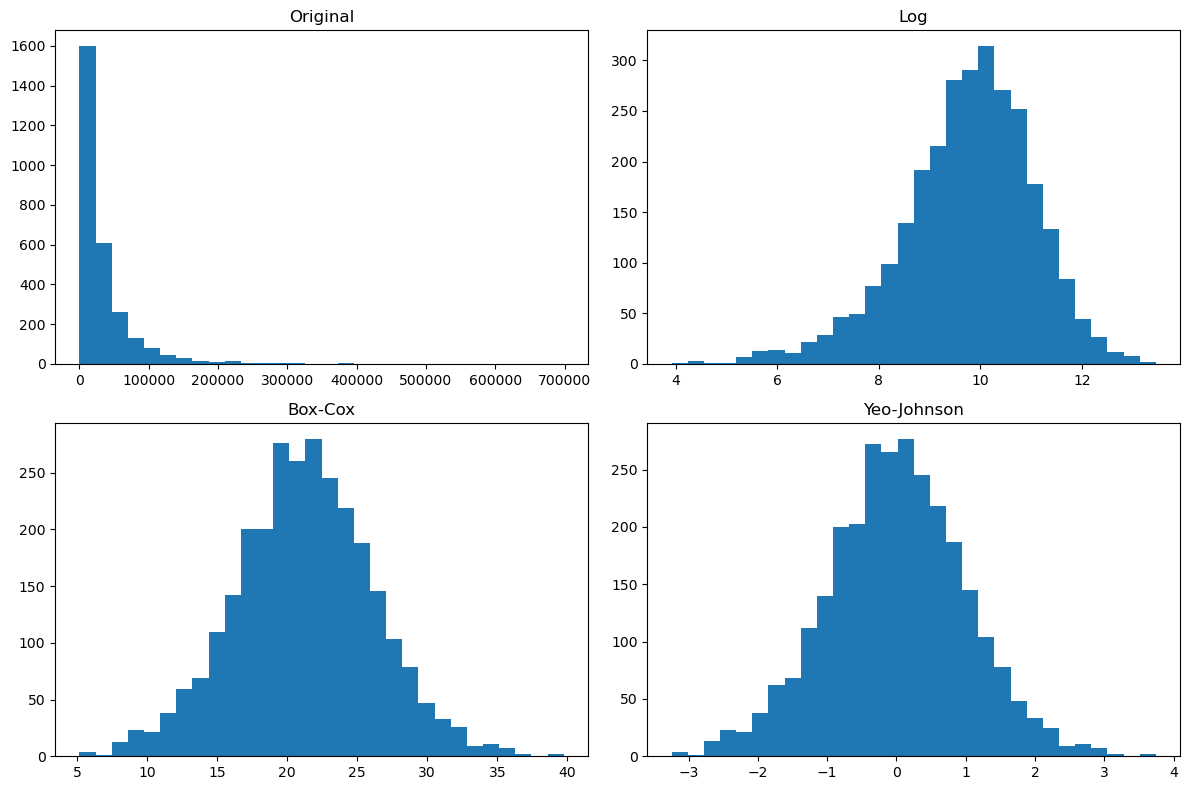

In [49]:
fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].hist(gmm_trans['monto_pagado'], bins=30)
ax[0,0].set_title('Original')

ax[0,1].hist(gmm_trans['log'], bins=30)
ax[0,1].set_title('Log')

ax[1,0].hist(gmm_trans['boxcox'], bins=30)
ax[1,0].set_title('Box-Cox')

ax[1,1].hist(gmm_trans['yeojohnson'], bins=30)
ax[1,1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

## QQ Plots

### Accidentes Personales

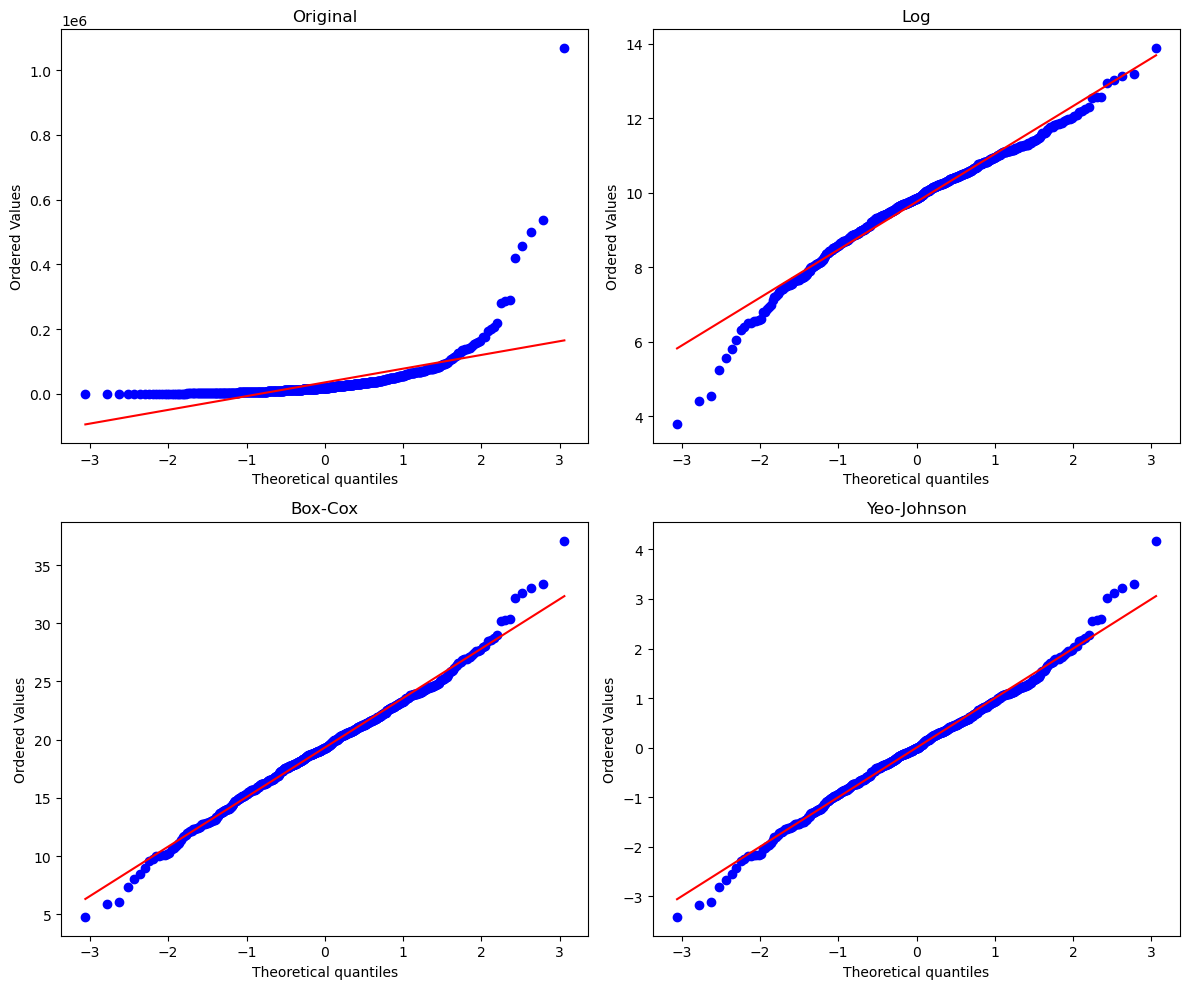

In [50]:
fig, ax = plt.subplots(2,2,figsize=(12,10))

stats.probplot(
    ap_trans['monto_pagado'],
    dist='norm',
    plot=ax[0,0]
)

ax[0,0].set_title('Original')

stats.probplot(
    ap_trans['log'],
    dist='norm',
    plot=ax[0,1]
)

ax[0,1].set_title('Log')

stats.probplot(
    ap_trans['boxcox'],
    dist='norm',
    plot=ax[1,0]
)

ax[1,0].set_title('Box-Cox')

stats.probplot(
    ap_trans['yeojohnson'],
    dist='norm',
    plot=ax[1,1]
)

ax[1,1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

In [51]:
# Pruebas de normalidad
variables = [
    'monto_pagado',
    'log',
    'boxcox',
    'yeojohnson'
]

for var in variables:

    stat, p = shapiro(
        ap_trans[var]
        .sample(
            min(5000, len(ap_trans)),
            random_state=123
        )
    )

    print(f'{var}: p-value = {p:.5f}')

monto_pagado: p-value = 0.00000
log: p-value = 0.00000
boxcox: p-value = 0.00332
yeojohnson: p-value = 0.00339


In [52]:
print('En la cartera de Accidentes Personales, ninguna de las transformaciones logra que la variable monto pagado cumpla ' \
'\ncompletamente el supuesto de normalidad. No obstante, Box-Cox y Yeo-Johnson presentan el mejor desempeño al reducir ' \
'\nsignificativamente la asimetría observada en la distribución original.')

En la cartera de Accidentes Personales, ninguna de las transformaciones logra que la variable monto pagado cumpla 
completamente el supuesto de normalidad. No obstante, Box-Cox y Yeo-Johnson presentan el mejor desempeño al reducir 
significativamente la asimetría observada en la distribución original.


### GMM

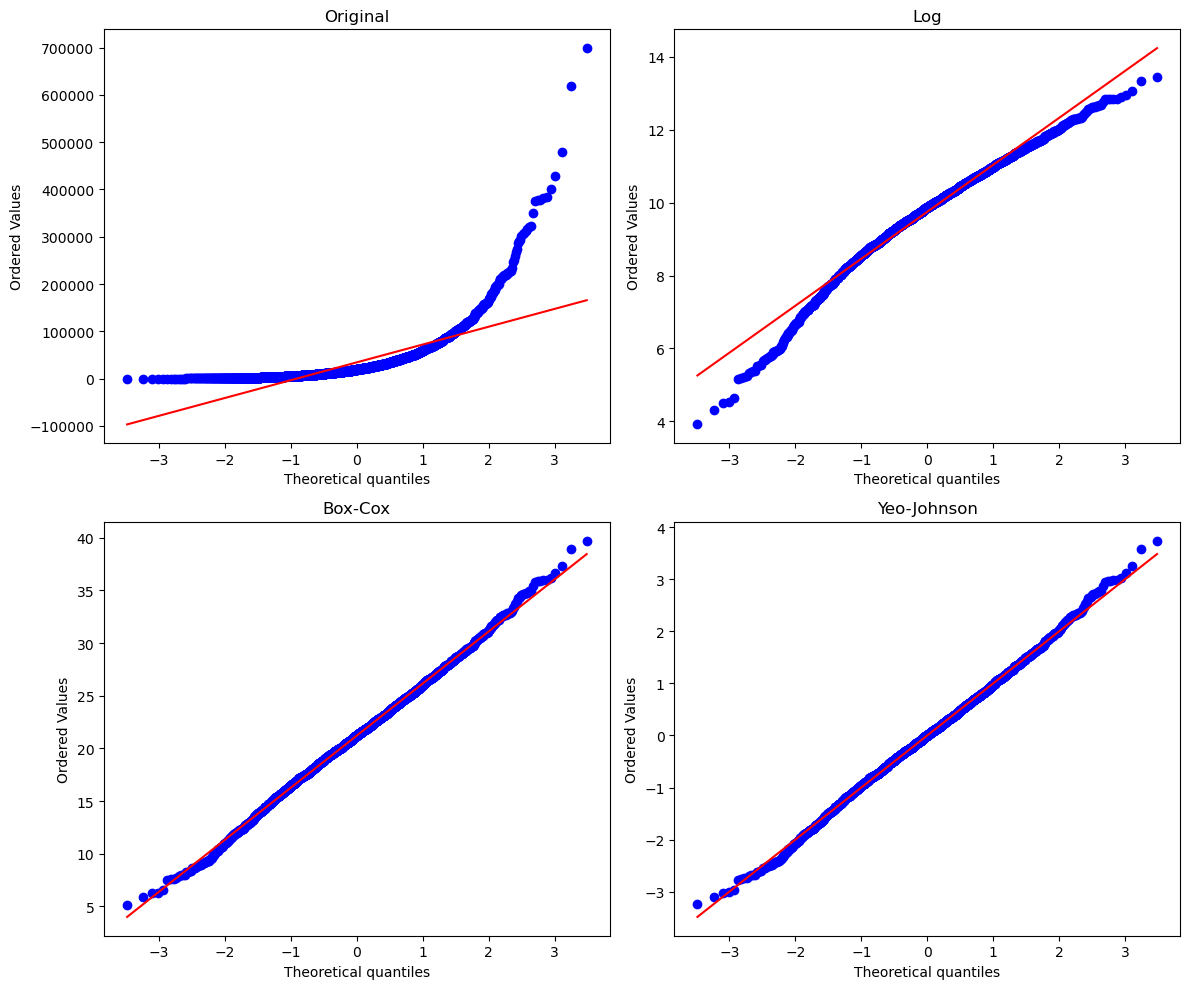

In [53]:
fig, ax = plt.subplots(2,2,figsize=(12,10))

stats.probplot(
    gmm_trans['monto_pagado'],
    dist='norm',
    plot=ax[0,0]
)

ax[0,0].set_title('Original')

stats.probplot(
    gmm_trans['log'],
    dist='norm',
    plot=ax[0,1]
)

ax[0,1].set_title('Log')

stats.probplot(
    gmm_trans['boxcox'],
    dist='norm',
    plot=ax[1,0]
)

ax[1,0].set_title('Box-Cox')

stats.probplot(
    gmm_trans['yeojohnson'],
    dist='norm',
    plot=ax[1,1]
)

ax[1,1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

In [54]:
for var in variables:

    stat, p = shapiro(
        gmm_trans[var]
        .sample(
            min(5000, len(ap_trans)),
            random_state=123
        )
    )

    print(f'{var}: p-value = {p:.5f}')

monto_pagado: p-value = 0.00000
log: p-value = 0.00000
boxcox: p-value = 0.12396
yeojohnson: p-value = 0.12516


In [55]:
print('En la cartera de Gastos Médicos Mayores, las transformaciones Box-Cox y Yeo-Johnson logran una aproximación adecuada ' \
'\na la distribución normal, ya que los p-values obtenidos son superiores al nivel de significancia de 0.05. Esto indica que, ' \
'\ndespués de aplicar dichas transformaciones, no existe evidencia estadística suficiente para rechazar la hipótesis de normalidad. ' \
'\nLa transformación logarítmica mejora la distribución, pero no alcanza el mismo nivel de ajuste observado con Box-Cox y Yeo-Johnson.')

En la cartera de Gastos Médicos Mayores, las transformaciones Box-Cox y Yeo-Johnson logran una aproximación adecuada 
a la distribución normal, ya que los p-values obtenidos son superiores al nivel de significancia de 0.05. Esto indica que, 
después de aplicar dichas transformaciones, no existe evidencia estadística suficiente para rechazar la hipótesis de normalidad. 
La transformación logarítmica mejora la distribución, pero no alcanza el mismo nivel de ajuste observado con Box-Cox y Yeo-Johnson.


## Variables derivadas

### Accidentes personales

In [56]:
ap['mayor65'] = (ap['edad'] >= 65).astype(int)

In [57]:
ap_sin['siniestro_alto'] = (ap_sin['monto_pagado'] > 25000).astype(int)
print(ap_sin['siniestro_alto'].sum())

263


### GMM

In [58]:
gmm['mayor65'] = (gmm['edad'] >= 65).astype(int)

In [59]:
gmm_sin['siniestro_alto'] = (gmm_sin['monto_pagado'] > 200000).astype(int)
print(gmm_sin['siniestro_alto'].sum())

45


In [60]:
resumen_altos = pd.DataFrame({
    'AP': [
        ap_sin['siniestro_alto'].sum(),
        100*ap_sin['siniestro_alto'].mean()
    ],

    'GMM': [
        gmm_sin['siniestro_alto'].sum(),
        100*gmm_sin['siniestro_alto'].mean()
    ]

},

index=[
    'Numero Siniestros Altos',
    '% del Total'
])

resumen_altos

,AP,GMM
Numero Siniestros Altos,263.000000,45.000000
% del Total,42.215088,1.599716


In [61]:
print('Notemos que el % en Accidentes personales es mayor que en GMM, es el portafolio que presenta mas siniestros altos')


Notemos que el % en Accidentes personales es mayor que en GMM, es el portafolio que presenta mas siniestros altos


## Calculo de promedios

### Accidentes personales

In [62]:
media_sexo_ap = (
    ap_sin
    .groupby('sexo')['monto_pagado']
    .mean()
    .reset_index()
)

media_sexo_ap['monto_pagado'] = (
    media_sexo_ap['monto_pagado']
    .map(lambda x: f'${x:,.2f}')
)

media_sexo_ap

/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/3731262766.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sexo')['monto_pagado']


,sexo,monto_pagado
0,F,"$40,646.31"
1,M,"$30,901.15"


In [63]:
media_anio_ap = (
    ap_sin
    .groupby('año_inicio')['monto_pagado']
    .mean()
    .reset_index()
)

media_anio_ap['monto_pagado'] = (
    media_anio_ap['monto_pagado']
    .map(lambda x: f'${x:,.2f}')
)

media_anio_ap

,año_inicio,monto_pagado
0,2019,"$30,474.39"
1,2020,"$39,519.25"
2,2021,"$40,224.64"
3,2022,"$38,292.05"
4,2023,"$36,055.92"
5,2024,"$30,870.54"


In [64]:
media_plan_ap = (
    ap_sin
    .groupby('plan')['monto_pagado']
    .mean()
    .reset_index()
    .sort_values('monto_pagado', ascending=False)
)

media_plan_ap['monto_pagado'] = (
    media_plan_ap['monto_pagado']
    .map(lambda x: f'${x:,.2f}')
)

media_plan_ap

/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/2097844951.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')['monto_pagado']


,plan,monto_pagado
7,Individual,"$36,931.70"
6,Familiar,"$34,739.71"
0,10 anios,$nan
1,20 anios,$nan
2,Amplia,$nan
3,Amplia Plus,$nan
4,Basico,$nan
5,Elite,$nan
8,Permanente,$nan
9,Plus,$nan


/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/3234959719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sexo')['monto_pagado']
/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/3234959719.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')['monto_pagado']


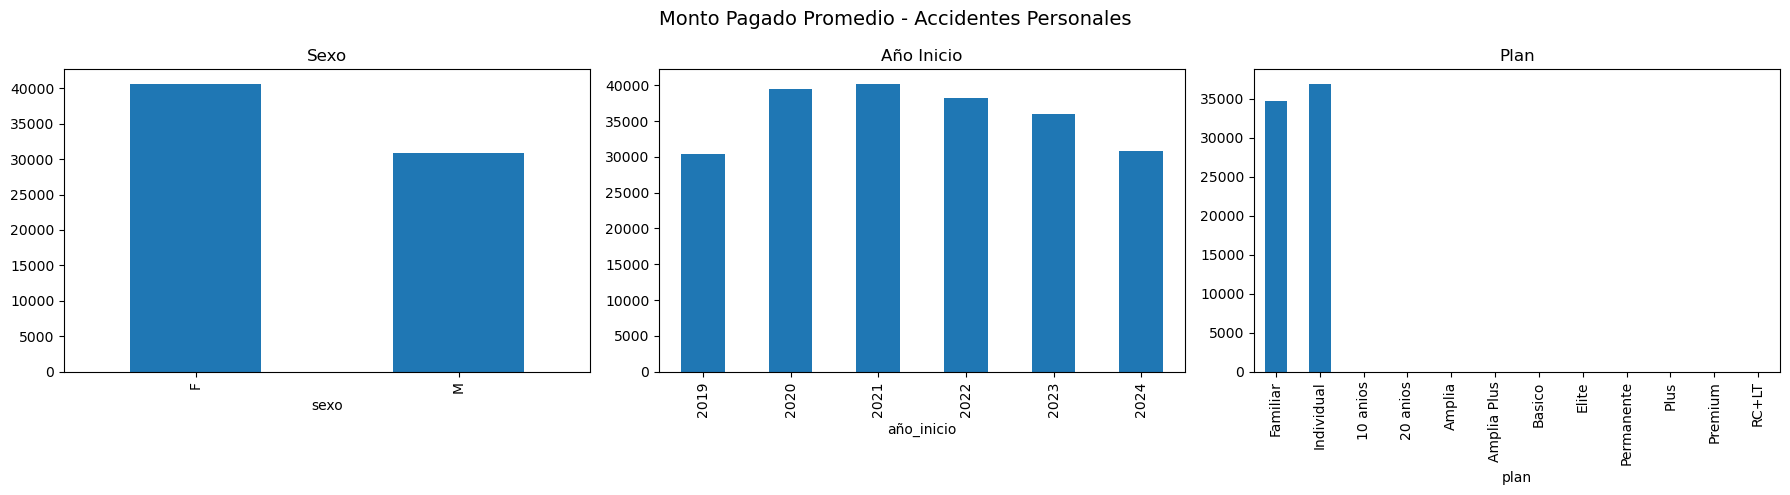

In [ ]:
# Para mejor visualizacion juntamos los resultados en graficas
fig, ax = plt.subplots(1,3,figsize=(18,5))

(
    ap_sin
    .groupby('sexo')['monto_pagado']
    .mean()
    .plot(kind='bar', ax=ax[0])
)

ax[0].set_title('Sexo')


(
    ap_sin
    .groupby('año_inicio')['monto_pagado']
    .mean()
    .plot(kind='bar', ax=ax[1])
)

ax[1].set_title('Año Inicio')


(
    ap_sin
    .groupby('plan')['monto_pagado']
    .mean()
    .sort_values()
    .plot(kind='bar', ax=ax[2])
)

ax[2].set_title('Plan')

plt.suptitle(
    'Monto Pagado Promedio - Accidentes Personales',
    fontsize=14
)

plt.tight_layout()

plt.show()

In [66]:
print('Aqui ya estamos analizando el monto pagado, notemos que hay mas hombres siniestrados que mujeres ' \
'\ny 2020 y 2021 son los años de inicio de vigencia de la poliza con mas siniestros ')


Aqui ya estamos analizando el monto pagado, notemos que hay mas hombres siniestrados que mujeres 
y 2020 y 2021 son los años de inicio de vigencia de la poliza con mas siniestros 


### GMM

/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/2882074475.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sexo')['monto_pagado']
/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_62716/2882074475.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')['monto_pagado']


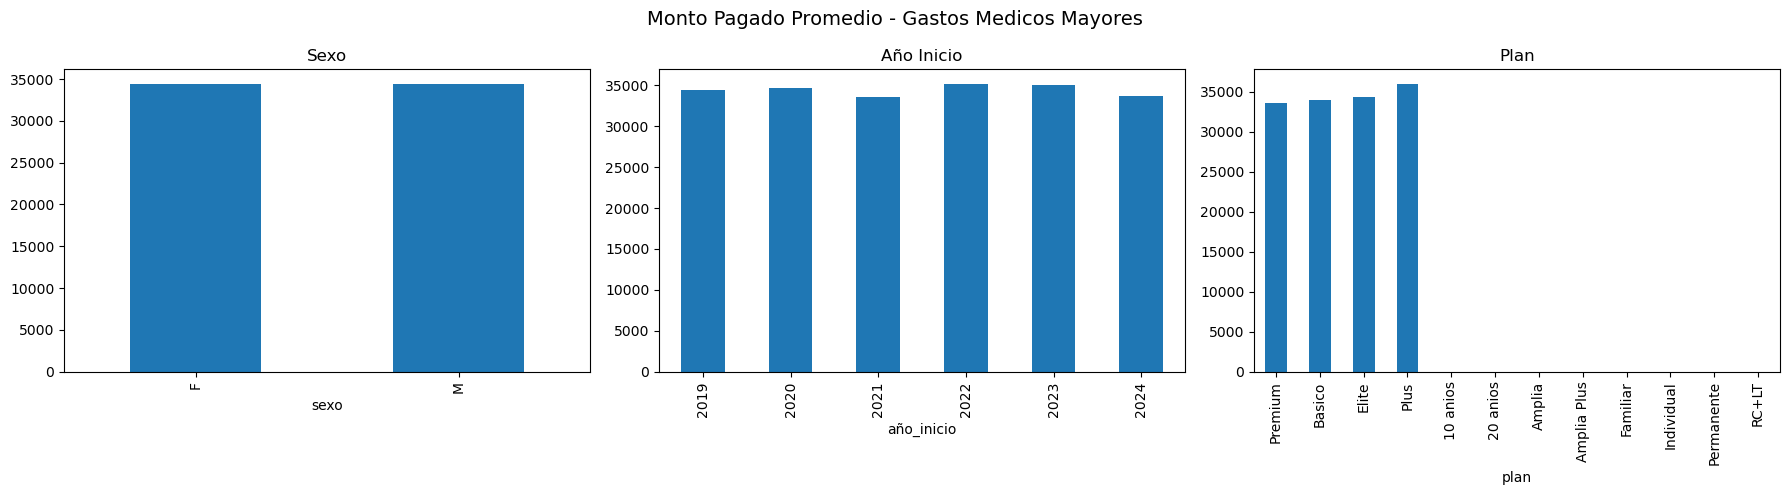

In [67]:
fig, ax = plt.subplots(1,3,figsize=(18,5))

(
    gmm_sin
    .groupby('sexo')['monto_pagado']
    .mean()
    .plot(kind='bar', ax=ax[0])
)

ax[0].set_title('Sexo')


(
    gmm_sin
    .groupby('año_inicio')['monto_pagado']
    .mean()
    .plot(kind='bar', ax=ax[1])
)

ax[1].set_title('Año Inicio')


(
    gmm_sin
    .groupby('plan')['monto_pagado']
    .mean()
    .sort_values()
    .plot(kind='bar', ax=ax[2])
)

ax[2].set_title('Plan')

plt.suptitle(
    'Monto Pagado Promedio - Gastos Medicos Mayores',
    fontsize=14
)

plt.tight_layout()

plt.show()

In [68]:
print('Para el caso de GMM, notemos que las personas siniestradas matienen una constante en sus variables,' \
'\npor ejemplo, en promedio la cantidad de hombres siniestradas es similar a la cantidad de mujeres')

Para el caso de GMM, notemos que las personas siniestradas matienen una constante en sus variables,
por ejemplo, en promedio la cantidad de hombres siniestradas es similar a la cantidad de mujeres
